# Notebook 2 – EDA & Feature Engineering

**Tujuan:** Eksplorasi data secara mendalam (EDA) dan dokumentasi **182 fitur**
(164 kanonik + 18 Double-Dummy Solver) yang diekstrak dari setiap board.

**Output yang dihasilkan:** `outputs/results/nb02_*.png`

**Tahap penelitian:** Tahap 3 (Feature Engineering) & Tahap 4 (Dataset)

> **Prasyarat:** Jalankan `01_data_extraction.ipynb` (folder ini) terlebih dahulu, atau pastikan `data/processed/` sudah ada.


---
## 0. Setup

In [1]:
import sys
import json
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

OUT = ROOT / 'outputs' / 'results'
OUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_palette('tab10')
print('Setup selesai.')


Setup selesai.


In [2]:
# Load dataset lengkap
df = pd.read_csv(ROOT / 'data' / 'processed' / 'full.csv')
feature_cols = json.loads((ROOT / 'data' / 'processed' / 'feature_columns.json').read_text())

print(f'Dataset shape : {df.shape}')
print(f'Fitur         : {len(feature_cols)}')
print(f'Target unik   : {df["target_base"].nunique()} kelas')
print(f'\nKolom target yang tersedia:')
for col in ['target', 'target_base', 'target_category', 'label']:
    if col in df.columns:
        print(f'  {col:<18}: {df[col].nunique()} nilai unik')


Dataset shape : (49755, 192)
Fitur         : 182
Target unik   : 36 kelas

Kolom target yang tersedia:
  target            : 88 nilai unik
  target_base       : 36 nilai unik
  target_category   : 5 nilai unik
  label             : 36 nilai unik


---
## 1. Struktur Fitur

In [3]:
# Kelompokkan fitur berdasarkan prefix
def group_features(cols):
    groups = {
        'Hand N (North)':     [c for c in cols if c.startswith('N_')],
        'Hand E (East)':      [c for c in cols if c.startswith('E_')],
        'Hand S (South)':     [c for c in cols if c.startswith('S_')],
        'Hand W (West)':      [c for c in cols if c.startswith('W_')],
        'Partnership NS':     [c for c in cols if c.startswith('ns_') and not c.startswith('ns_dd')],
        'Partnership EW':     [c for c in cols if c.startswith('ew_') and not c.startswith('ew_dd')],
        'HCP Advantage':      [c for c in cols if 'advantage' in c],
        'Deal (Dealer)':      [c for c in cols if c.startswith('dealer_')],
        'Deal (Vuln)':        [c for c in cols if c.startswith('vuln_')],
        'Auction':            [c for c in cols if c.startswith('auction_') or c.startswith('opening_')],
        'Double-Dummy Solver': [c for c in cols if c.startswith('ns_dd') or c.startswith('ew_dd') or c.startswith('dd_par')],
    }
    return groups

groups = group_features(feature_cols)

print(f'{"Kelompok Fitur":<25} {"Jumlah":>7}  Contoh')
print('-' * 75)
for name, cols in groups.items():
    examples = ', '.join(cols[:3]) + (' ...' if len(cols) > 3 else '')
    print(f'{name:<25} {len(cols):>7}  {examples}')
print('-' * 75)
print(f'{"TOTAL":<25} {sum(len(v) for v in groups.values()):>7}')


Kelompok Fitur             Jumlah  Contoh
---------------------------------------------------------------------------
Hand N (North)                 24  N_hcp, N_hcp_S, N_len_S ...
Hand E (East)                  24  E_hcp, E_hcp_S, E_len_S ...
Hand S (South)                 24  S_hcp, S_hcp_S, S_len_S ...
Hand W (West)                  24  W_hcp, W_hcp_S, W_len_S ...
Partnership NS                 22  ns_hcp, ns_ltc, ns_controls ...
Partnership EW                 22  ew_hcp, ew_ltc, ew_controls ...
HCP Advantage                   1  hcp_ns_advantage
Deal (Dealer)                   4  dealer_N, dealer_E, dealer_S ...
Deal (Vuln)                     4  vuln_none, vuln_ns, vuln_ew ...
Auction                        15  auction_len, auction_ns_bids, auction_ew_bids ...
Double-Dummy Solver            18  ns_dd_S, ew_dd_S, ns_dd_H ...
---------------------------------------------------------------------------
TOTAL                         182


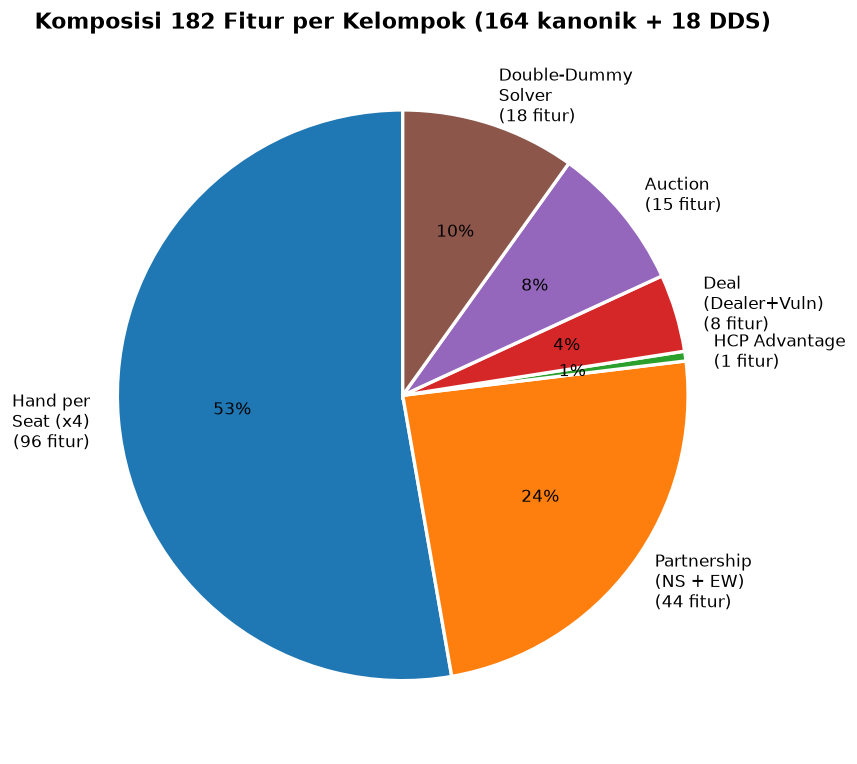

In [4]:
# Pie chart distribusi kelompok fitur
group_summary = {
    'Hand per\nSeat (x4)': sum(len(v) for k, v in groups.items() if k.startswith('Hand')),
    'Partnership\n(NS + EW)': len(groups['Partnership NS']) + len(groups['Partnership EW']),
    'HCP Advantage': len(groups['HCP Advantage']),
    'Deal\n(Dealer+Vuln)': len(groups['Deal (Dealer)']) + len(groups['Deal (Vuln)']),
    'Auction': len(groups['Auction']),
    'Double-Dummy\nSolver': len(groups['Double-Dummy Solver']),
}

fig, ax = plt.subplots(figsize=(7.5, 6.5))
pie_cols = sns.color_palette('tab10', len(group_summary))
wedges, texts, autotexts = ax.pie(
    group_summary.values(),
    labels=[f'{k}\n({v} fitur)' for k, v in group_summary.items()],
    colors=pie_cols,
    autopct='%1.0f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 10},
)
for at in autotexts:
    at.set_fontsize(10)
ax.set_title(f'Komposisi 182 Fitur per Kelompok (164 kanonik + 18 DDS)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUT / 'nb02_feature_groups.png', bbox_inches='tight')
plt.show()


In [5]:
# Daftar lengkap fitur per kelompok
print('=== DAFTAR FITUR PER KELOMPOK ===')
for group_name, cols in groups.items():
    print(f'\n[{group_name}]  ({len(cols)} fitur)')
    sample_cols = cols[:4]
    stats = df[sample_cols].describe().loc[['mean', 'std', 'min', 'max']].round(2)
    print(stats.to_string())
    if len(cols) > 4:
        print(f'  ... dan {len(cols)-4} fitur lainnya')


=== DAFTAR FITUR PER KELOMPOK ===

[Hand N (North)]  (24 fitur)
      N_hcp  N_hcp_S  N_len_S  N_stopper_S
mean  10.01     2.51     3.26         0.59
std    4.13     2.32     1.37         0.49
min    0.00     0.00     0.00         0.00
max   27.00    10.00     9.00         1.00
  ... dan 20 fitur lainnya

[Hand E (East)]  (24 fitur)
      E_hcp  E_hcp_S  E_len_S  E_stopper_S
mean   9.93     2.48     3.24         0.59
std    4.16     2.31     1.35         0.49
min    0.00     0.00     0.00         0.00
max   30.00    10.00     9.00         1.00
  ... dan 20 fitur lainnya

[Hand S (South)]  (24 fitur)
      S_hcp  S_hcp_S  S_len_S  S_stopper_S
mean  10.05     2.52     3.26         0.60
std    4.15     2.31     1.36         0.49
min    0.00     0.00     0.00         0.00
max   28.00    10.00     8.00         1.00
  ... dan 20 fitur lainnya

[Hand W (West)]  (24 fitur)
      W_hcp  W_hcp_S  W_len_S  W_stopper_S
mean  10.01     2.48     3.24         0.59
std    4.13     2.30     1.37       

---
## 2. EDA – Distribusi HCP

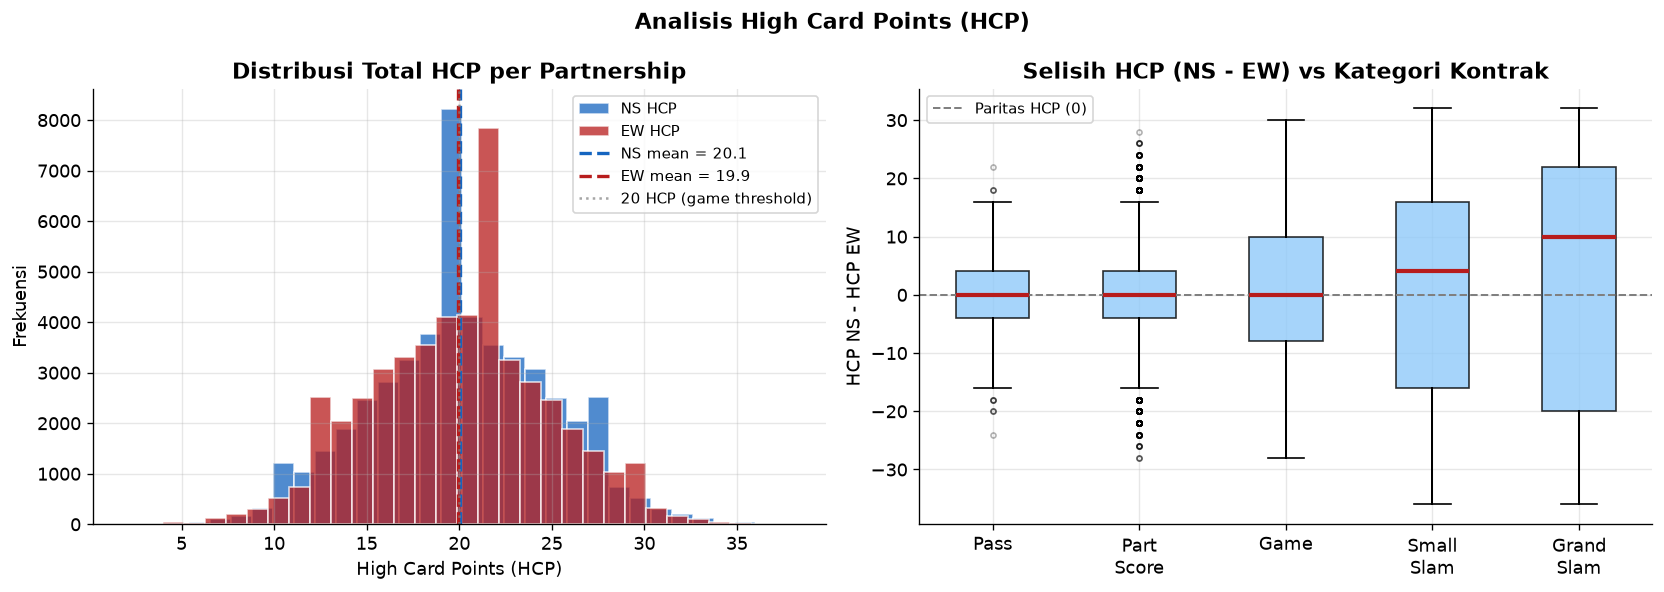

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(df['ns_hcp'], bins=30, alpha=0.75, label='NS HCP', color='#1565C0', edgecolor='white')
ax.hist(df['ew_hcp'], bins=30, alpha=0.75, label='EW HCP', color='#B71C1C', edgecolor='white')
ax.axvline(df['ns_hcp'].mean(), color='#1565C0', linestyle='--', lw=2,
           label=f'NS mean = {df["ns_hcp"].mean():.1f}')
ax.axvline(df['ew_hcp'].mean(), color='#B71C1C', linestyle='--', lw=2,
           label=f'EW mean = {df["ew_hcp"].mean():.1f}')
ax.axvline(20, color='gray', linestyle=':', lw=1.5, alpha=0.7, label='20 HCP (game threshold)')
ax.set_title('Distribusi Total HCP per Partnership', fontweight='bold')
ax.set_xlabel('High Card Points (HCP)')
ax.set_ylabel('Frekuensi')
ax.legend(fontsize=9)

ax = axes[1]
cat_order_box = ['Pass', 'Partscore', 'Game', 'SmallSlam', 'GrandSlam']
cat_labels_box = ['Pass', 'Part\nScore', 'Game', 'Small\nSlam', 'Grand\nSlam']
data_box = [df[df['target_category'] == c]['hcp_ns_advantage'].dropna()
            for c in cat_order_box]
bp = ax.boxplot(
    data_box, tick_labels=cat_labels_box, patch_artist=True,
    boxprops=dict(facecolor='#90CAF9', alpha=0.8),
    medianprops=dict(color='#B71C1C', linewidth=2.5),
    whiskerprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.3),
)
ax.axhline(0, color='gray', linestyle='--', lw=1.2, label='Paritas HCP (0)')
ax.set_title('Selisih HCP (NS - EW) vs Kategori Kontrak', fontweight='bold')
ax.set_ylabel('HCP NS - HCP EW')
ax.legend(fontsize=9)

plt.suptitle('Analisis High Card Points (HCP)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'nb02_hcp_analysis.png', bbox_inches='tight')
plt.show()


---
## 3. EDA – Double-Dummy Solver (DDS)

Mengecek apakah trik DD dan kontrak par benar-benar berkorelasi kuat
dengan kontrak yang dibid, dan seberapa besar selisihnya (mengukur
ambiguitas bidding manusia secara kuantitatif).


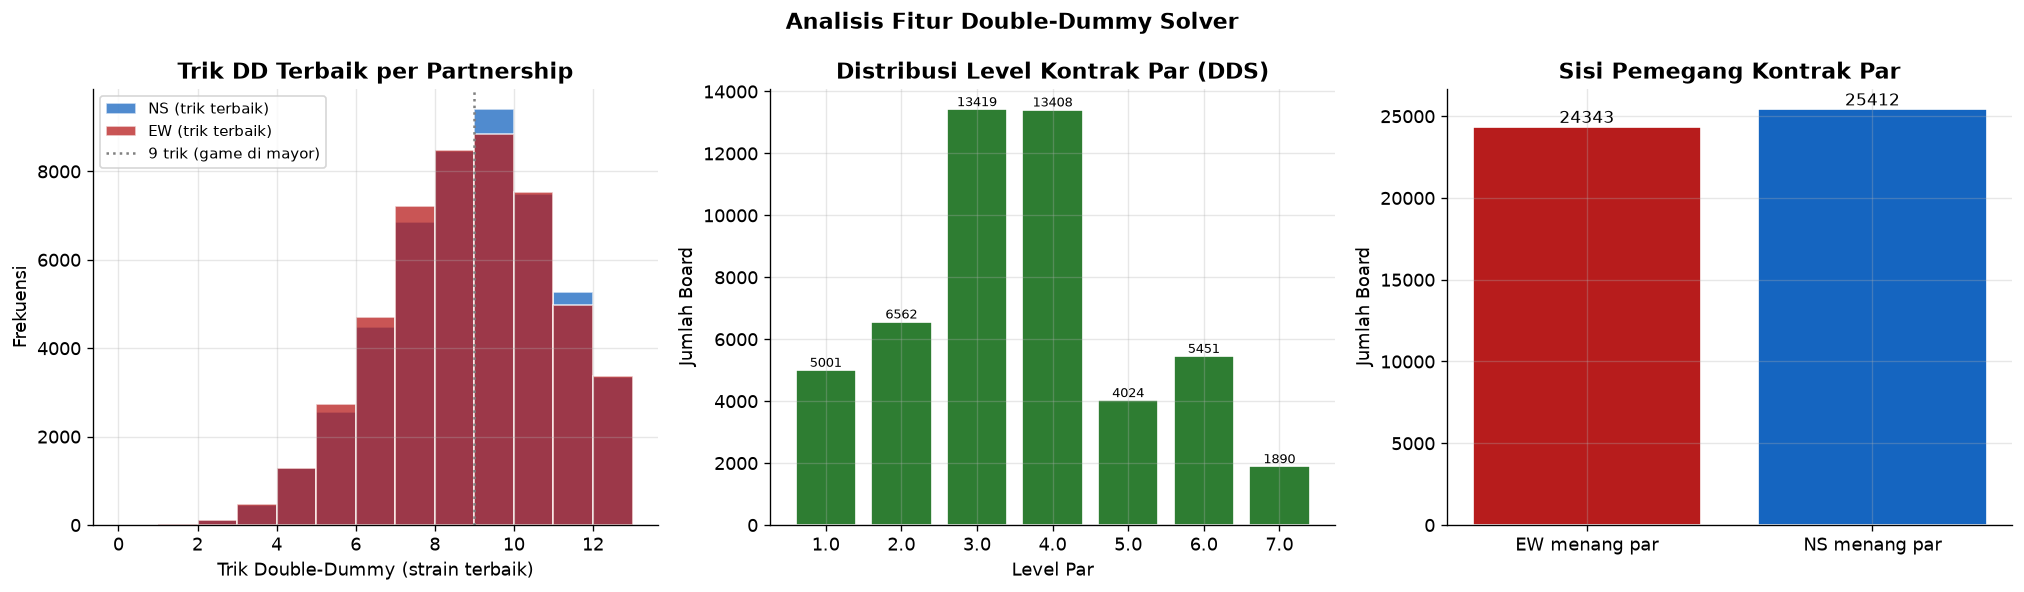

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# -- Distribusi trik DD NS vs EW --------------------------------------
ax = axes[0]
ns_best_dd = df[['ns_dd_S','ns_dd_H','ns_dd_D','ns_dd_C','ns_dd_N']].max(axis=1)
ew_best_dd = df[['ew_dd_S','ew_dd_H','ew_dd_D','ew_dd_C','ew_dd_N']].max(axis=1)
ax.hist(ns_best_dd, bins=range(0,14), alpha=0.75, label='NS (trik terbaik)', color='#1565C0', edgecolor='white')
ax.hist(ew_best_dd, bins=range(0,14), alpha=0.75, label='EW (trik terbaik)', color='#B71C1C', edgecolor='white')
ax.axvline(9, color='gray', linestyle=':', lw=1.5, label='9 trik (game di mayor)')
ax.set_title('Trik DD Terbaik per Partnership', fontweight='bold')
ax.set_xlabel('Trik Double-Dummy (strain terbaik)')
ax.set_ylabel('Frekuensi')
ax.legend(fontsize=9)

# -- Distribusi level par ----------------------------------------------
ax = axes[1]
par_cnt = df['dd_par_level'].value_counts().sort_index()
bars = ax.bar(par_cnt.index.astype(str), par_cnt.values, color='#2E7D32', edgecolor='white')
ax.bar_label(bars, fmt='%d', fontsize=8)
ax.set_title('Distribusi Level Kontrak Par (DDS)', fontweight='bold')
ax.set_xlabel('Level Par')
ax.set_ylabel('Jumlah Board')

# -- Sisi yang menang par -----------------------------------------------
ax = axes[2]
side_cnt = df['dd_par_declarer_is_ns'].value_counts()
labels_side = ['EW menang par', 'NS menang par']
vals_side = [side_cnt.get(0,0), side_cnt.get(1,0)]
bars = ax.bar(labels_side, vals_side, color=['#B71C1C', '#1565C0'], edgecolor='white')
ax.bar_label(bars, fmt='%d', fontsize=10)
ax.set_title('Sisi Pemegang Kontrak Par', fontweight='bold')
ax.set_ylabel('Jumlah Board')

plt.suptitle('Analisis Fitur Double-Dummy Solver', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'nb02_dds_analysis.png', bbox_inches='tight')
plt.show()


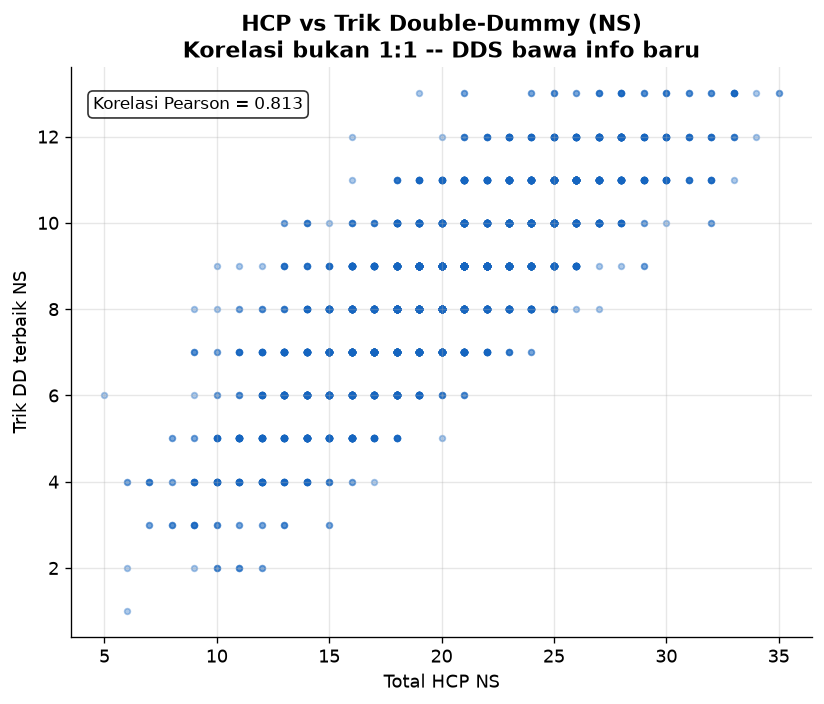

Korelasi HCP NS vs trik DD terbaik NS: 0.813
(< 1.0 secara signifikan -> DDS menangkap sesuatu yang tidak sepenuhnya sama dengan HCP)


In [8]:
# Korelasi trik DD dengan HCP (proxy lama) -- seberapa banyak info baru yang dibawa DDS?
fig, ax = plt.subplots(figsize=(7, 6))
sample_df = df.sample(n=min(3000, len(df)), random_state=42)
ax.scatter(sample_df['ns_hcp'], ns_best_dd.loc[sample_df.index], alpha=0.35, s=12, color='#1565C0')
ax.set_xlabel('Total HCP NS')
ax.set_ylabel('Trik DD terbaik NS')
ax.set_title('HCP vs Trik Double-Dummy (NS)\nKorelasi bukan 1:1 -- DDS bawa info baru', fontweight='bold')
corr_hcp_dd = df['ns_hcp'].corr(ns_best_dd)
ax.text(0.03, 0.95, f'Korelasi Pearson = {corr_hcp_dd:.3f}', transform=ax.transAxes,
        fontsize=10, va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.savefig(OUT / 'nb02_dds_vs_hcp.png', bbox_inches='tight')
plt.show()
print(f'Korelasi HCP NS vs trik DD terbaik NS: {corr_hcp_dd:.3f}')
print('(< 1.0 secara signifikan -> DDS menangkap sesuatu yang tidak sepenuhnya sama dengan HCP)')


---
## 4. EDA – Suit Fit & Stopper

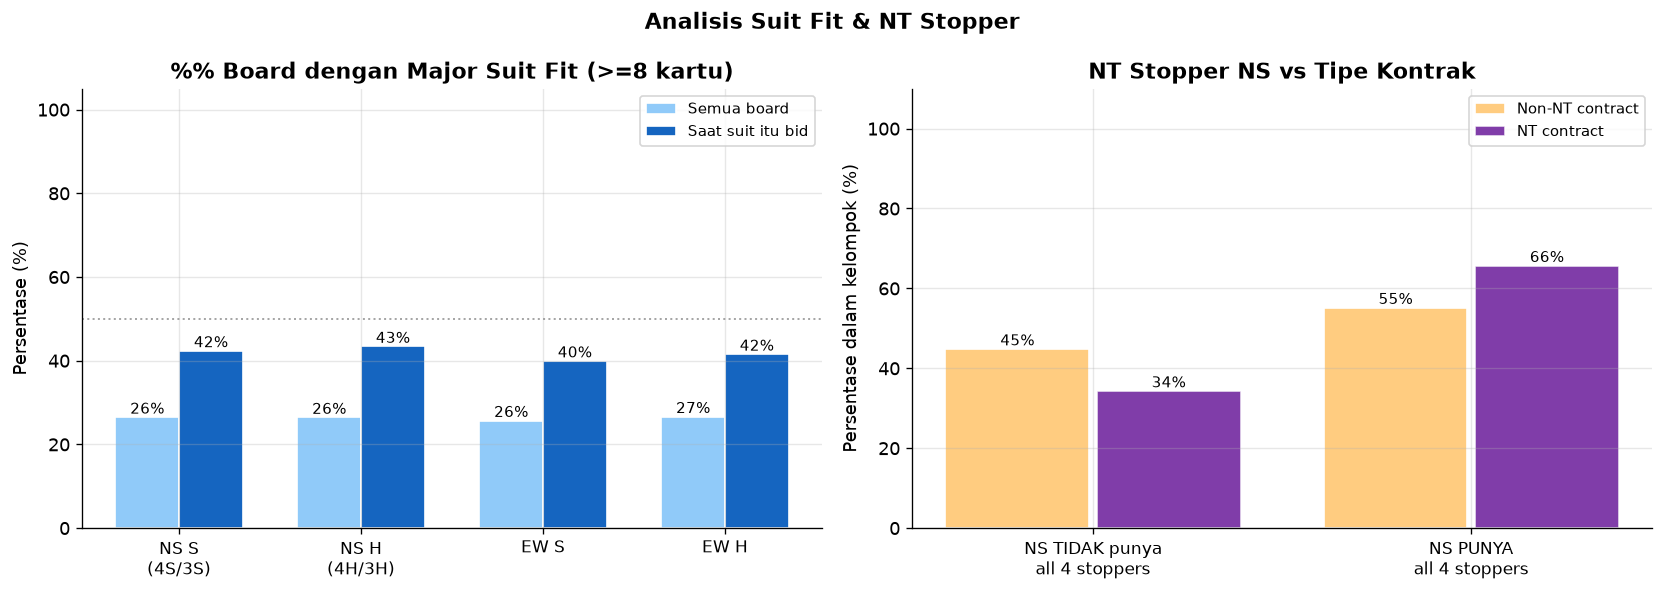

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
suit_categories = {
    'NS S\n(4S/3S)':  ('ns_has_fit_S', df['target_base'].str.endswith('S')),
    'NS H\n(4H/3H)':  ('ns_has_fit_H', df['target_base'].str.endswith('H')),
    'EW S':           ('ew_has_fit_S', df['target_base'].str.endswith('S')),
    'EW H':           ('ew_has_fit_H', df['target_base'].str.endswith('H')),
}
x_pos   = np.arange(len(suit_categories))
fit_pct_when_suit = []
fit_pct_overall   = []
for label, (fit_col, strain_mask) in suit_categories.items():
    overall  = df[fit_col].mean() * 100
    when_bid = df.loc[strain_mask, fit_col].mean() * 100
    fit_pct_overall.append(overall)
    fit_pct_when_suit.append(when_bid)

w = 0.35
bars1 = ax.bar(x_pos - w/2, fit_pct_overall,   w, label='Semua board',       color='#90CAF9', edgecolor='white')
bars2 = ax.bar(x_pos + w/2, fit_pct_when_suit, w, label='Saat suit itu bid', color='#1565C0', edgecolor='white')
ax.bar_label(bars1, fmt='%.0f%%', fontsize=9)
ax.bar_label(bars2, fmt='%.0f%%', fontsize=9)
ax.set_xticks(x_pos)
ax.set_xticklabels(list(suit_categories.keys()), fontsize=10)
ax.axhline(50, color='gray', linestyle=':', lw=1.2, alpha=0.7)
ax.set_title('%% Board dengan Major Suit Fit (>=8 kartu)', fontweight='bold')
ax.set_ylabel('Persentase (%)')
ax.set_ylim(0, 105)
ax.legend(fontsize=9)

ax = axes[1]
nt_contracts  = df['target_base'].str.endswith('N') & (df['target_base'] != 'PASS')
non_nt        = ~nt_contracts & (df['target_base'] != 'PASS')
stopper_nt     = df.loc[nt_contracts, 'ns_nt_stoppers'].value_counts(normalize=True).sort_index() * 100
stopper_non_nt = df.loc[non_nt, 'ns_nt_stoppers'].value_counts(normalize=True).sort_index() * 100

x_s = np.array([0, 1])
ax.bar(x_s - 0.2, [stopper_non_nt.get(0,0), stopper_non_nt.get(1,0)],
       0.38, label='Non-NT contract', color='#FFCC80', edgecolor='white')
ax.bar(x_s + 0.2, [stopper_nt.get(0,0), stopper_nt.get(1,0)],
       0.38, label='NT contract', color='#6A1B9A', edgecolor='white', alpha=0.85)
ax.set_xticks([0, 1])
ax.set_xticklabels(['NS TIDAK punya\nall 4 stoppers', 'NS PUNYA\nall 4 stoppers'], fontsize=10)
ax.set_title('NT Stopper NS vs Tipe Kontrak', fontweight='bold')
ax.set_ylabel('Persentase dalam kelompok (%)')
ax.set_ylim(0, 110)
ax.legend(fontsize=9)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', fontsize=9)

plt.suptitle('Analisis Suit Fit & NT Stopper', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'nb02_fit_stopper.png', bbox_inches='tight')
plt.show()


---
## 5. EDA – Losing Trick Count (LTC) & Kontrak

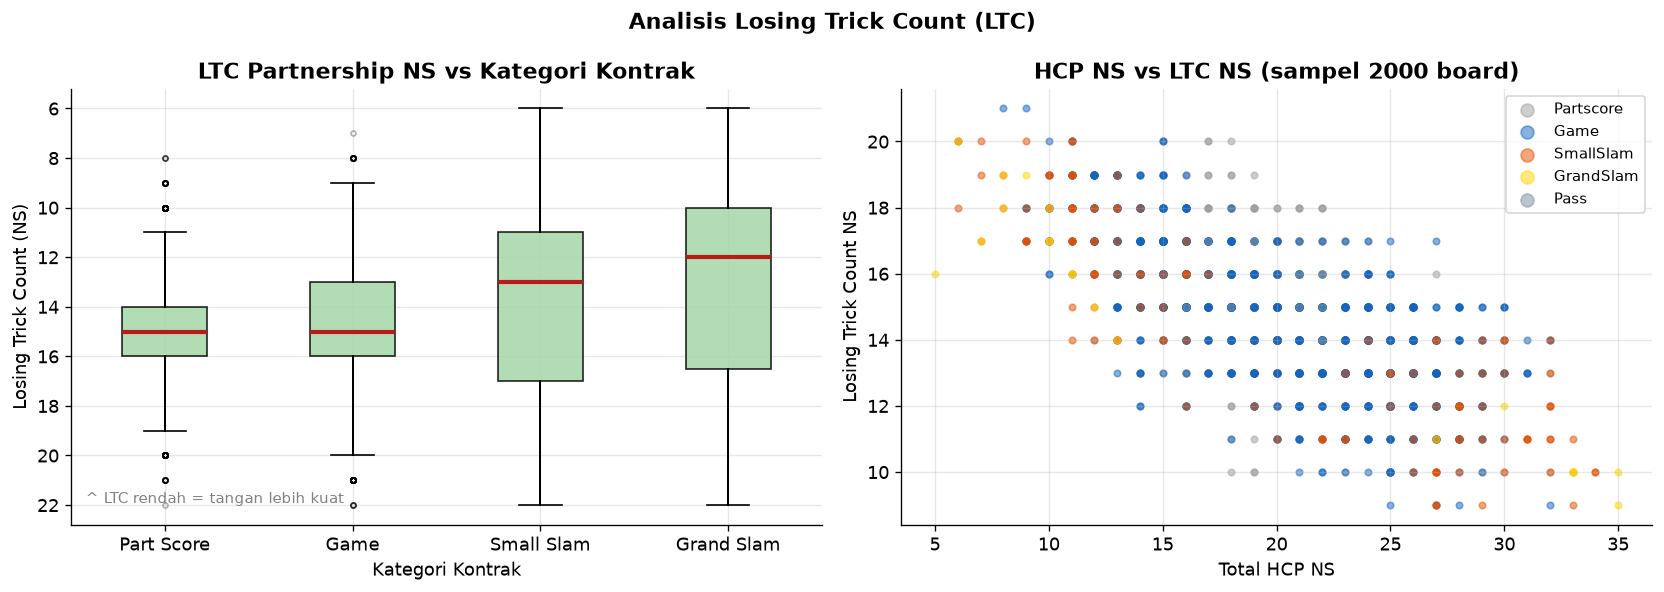

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
cat_order_ltc  = ['Partscore', 'Game', 'SmallSlam', 'GrandSlam']
cat_labels_ltc = ['Part Score', 'Game', 'Small Slam', 'Grand Slam']
ltc_data = [df[df['target_category'] == c]['ns_ltc'].dropna() for c in cat_order_ltc]
bp = ax.boxplot(
    ltc_data, tick_labels=cat_labels_ltc, patch_artist=True,
    boxprops=dict(facecolor='#A5D6A7', alpha=0.85),
    medianprops=dict(color='#B71C1C', linewidth=2.5),
    whiskerprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.3),
)
ax.set_title('LTC Partnership NS vs Kategori Kontrak', fontweight='bold')
ax.set_xlabel('Kategori Kontrak')
ax.set_ylabel('Losing Trick Count (NS)')
ax.invert_yaxis()
ax.text(0.02, 0.05, '^ LTC rendah = tangan lebih kuat', transform=ax.transAxes,
        fontsize=9, color='gray')

ax = axes[1]
sample_df = df.sample(n=min(2000, len(df)), random_state=42)
cat_color_map = {
    'Partscore': '#9E9E9E', 'Game': '#1565C0',
    'SmallSlam': '#E65100', 'GrandSlam': '#FFD700', 'Pass': '#78909C',
}
for cat, color in cat_color_map.items():
    mask = sample_df['target_category'] == cat
    ax.scatter(
        sample_df.loc[mask, 'ns_hcp'],
        sample_df.loc[mask, 'ns_ltc'],
        c=color, alpha=0.5, s=15, label=cat,
    )
ax.set_title('HCP NS vs LTC NS (sampel 2000 board)', fontweight='bold')
ax.set_xlabel('Total HCP NS')
ax.set_ylabel('Losing Trick Count NS')
ax.legend(fontsize=9, markerscale=2)

plt.suptitle('Analisis Losing Trick Count (LTC)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'nb02_ltc_analysis.png', bbox_inches='tight')
plt.show()


---
## 6. EDA – Fitur Auction

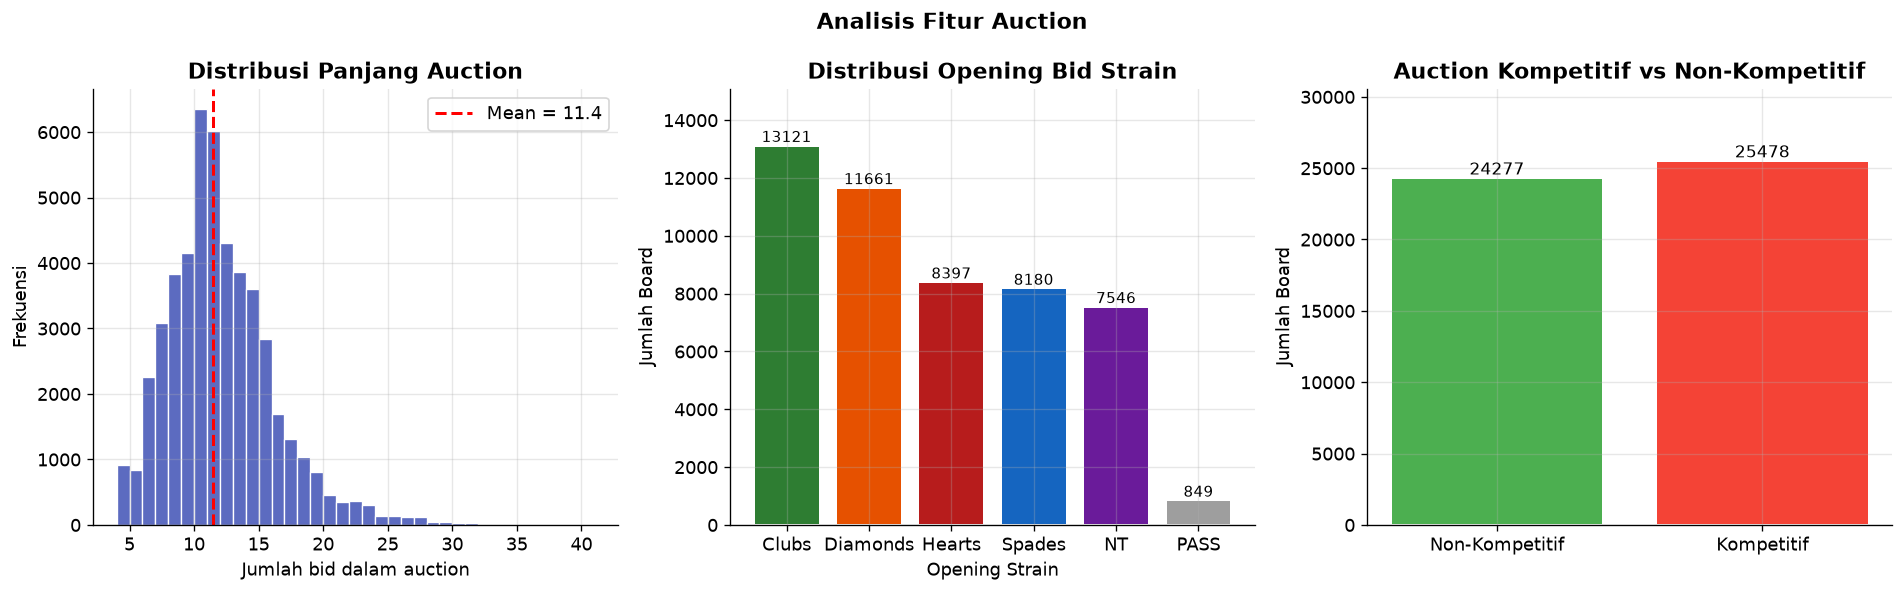

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.hist(df['auction_len'], bins=range(4, df['auction_len'].max()+2),
        color='#5C6BC0', edgecolor='white', linewidth=0.8)
ax.axvline(df['auction_len'].mean(), color='red', linestyle='--', lw=1.8,
           label=f'Mean = {df["auction_len"].mean():.1f}')
ax.set_title('Distribusi Panjang Auction', fontweight='bold')
ax.set_xlabel('Jumlah bid dalam auction')
ax.set_ylabel('Frekuensi')
ax.legend()

ax = axes[1]
opening_cols = ['opening_strain_C', 'opening_strain_D', 'opening_strain_H',
                'opening_strain_S', 'opening_strain_N', 'opening_strain_PASS']
opening_labels = ['Clubs', 'Diamonds', 'Hearts', 'Spades', 'NT', 'PASS']
opening_vals = [df[c].sum() for c in opening_cols]
oc = ['#2E7D32', '#E65100', '#B71C1C', '#1565C0', '#6A1B9A', '#9E9E9E']
bars = ax.bar(opening_labels, opening_vals, color=oc, edgecolor='white', linewidth=1.2)
ax.bar_label(bars, fmt='%d', fontsize=9)
ax.set_title('Distribusi Opening Bid Strain', fontweight='bold')
ax.set_xlabel('Opening Strain')
ax.set_ylabel('Jumlah Board')
ax.set_ylim(0, max(opening_vals) * 1.15)

ax = axes[2]
comp_cnt = df['auction_competitive'].value_counts()
labels_comp = ['Non-Kompetitif', 'Kompetitif']
vals_comp   = [comp_cnt.get(0, 0), comp_cnt.get(1, 0)]
bars = ax.bar(labels_comp, vals_comp, color=['#4CAF50', '#F44336'], edgecolor='white', linewidth=1.2)
ax.bar_label(bars, fmt='%d', fontsize=10)
ax.set_title('Auction Kompetitif vs Non-Kompetitif', fontweight='bold')
ax.set_ylabel('Jumlah Board')
ax.set_ylim(0, max(vals_comp) * 1.2)

plt.suptitle('Analisis Fitur Auction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'nb02_auction_features.png', bbox_inches='tight')
plt.show()


---
## 7. Dataset Split & Class Imbalance

In [12]:
from src.preprocessing import load_splits

df_train, df_val, df_test, feature_cols, le = load_splits(ROOT / 'data' / 'processed')

print('=== Dataset Split (group-aware) ===')
for name, split in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    pct = len(split) / (len(df_train)+len(df_val)+len(df_test)) * 100
    print(f'  {name:<6}: {len(split):>5,} board  ({pct:.0f}%)')
print(f'  Total : {len(df_train)+len(df_val)+len(df_test):>5,} board')
print(f'\nKelas : {len(le.classes_)}')
print(f'Fitur : {len(feature_cols)}')


=== Dataset Split (group-aware) ===
  Train : 34,832 board  (70%)
  Val   : 7,462 board  (15%)
  Test  : 7,461 board  (15%)
  Total : 49,755 board

Kelas : 36
Fitur : 182


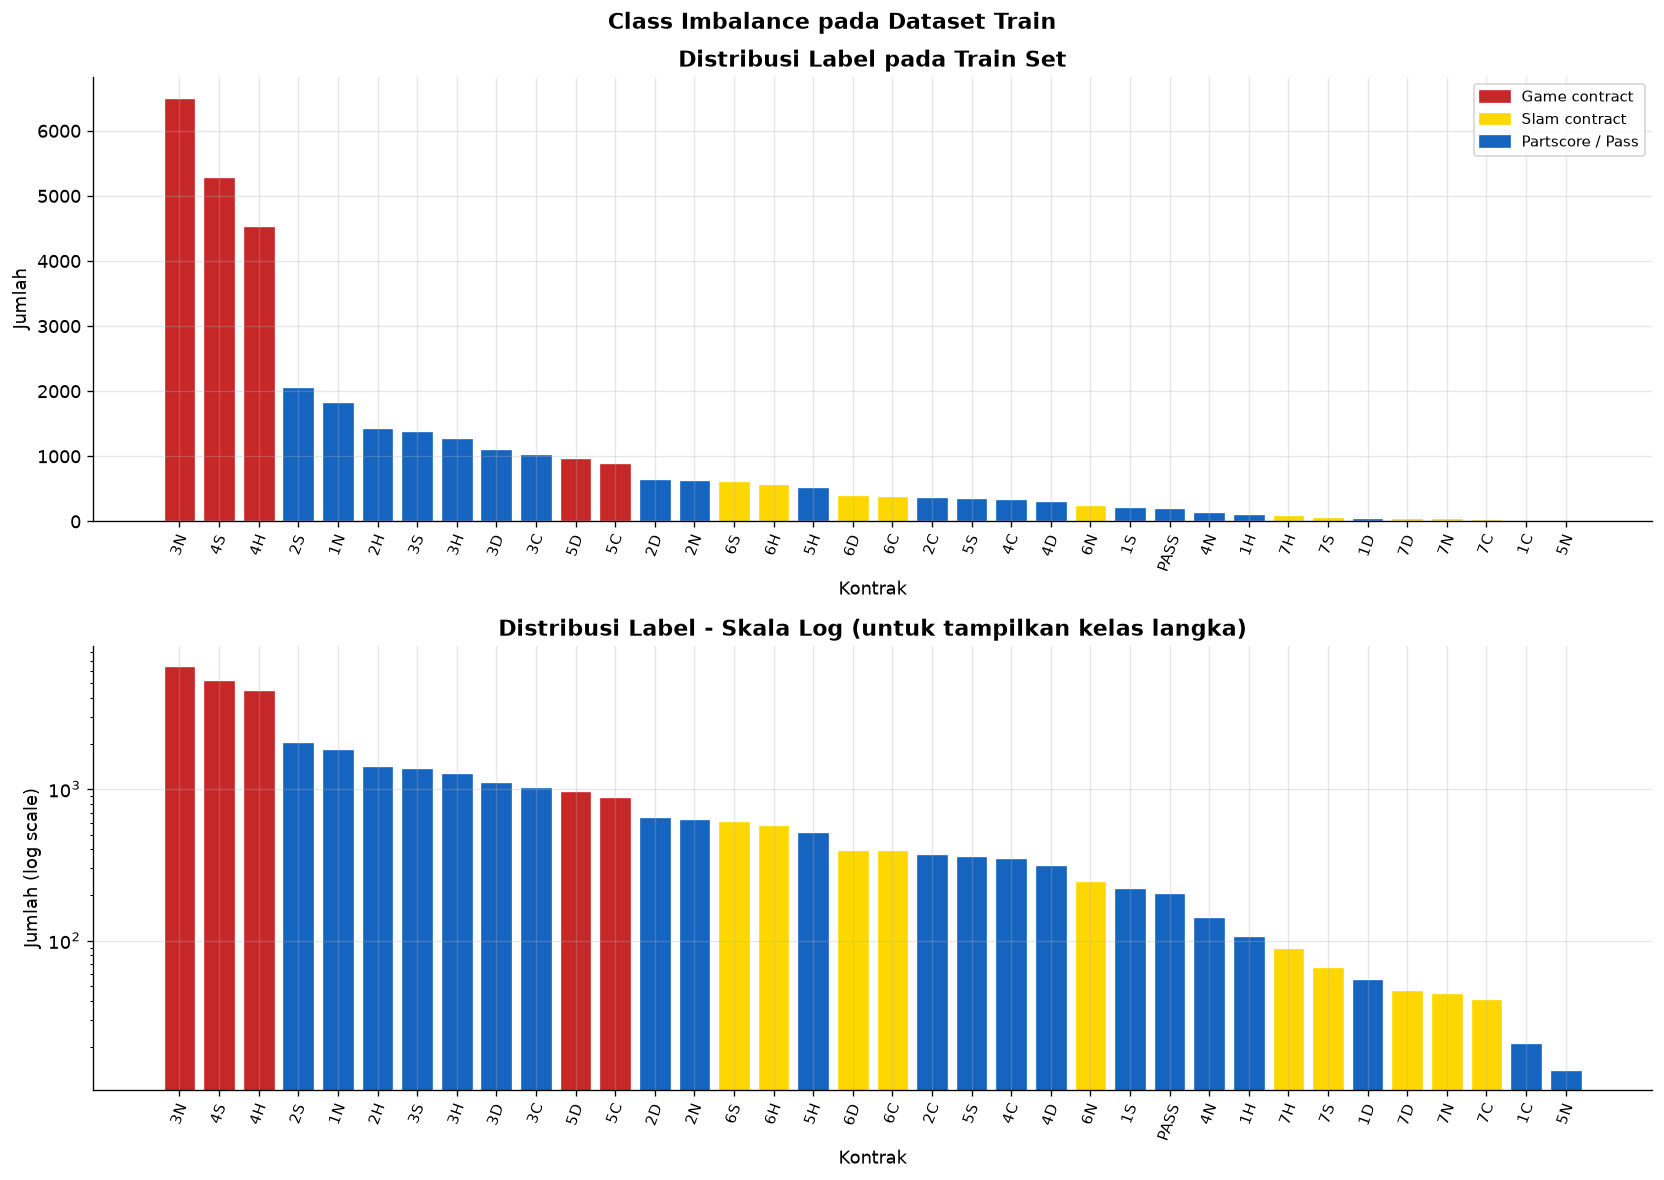


Kelas terbanyak : 3N  (6,506)
Kelas tersedikit: 5N (14)
Rasio imbalance : 465x


In [13]:
# Visualisasi distribusi label
label_counts = df_train['target_base'].value_counts()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

ax = axes[0]
game_set = {'3N', '4S', '4H', '5D', '5C'}
slam_set = {c for c in label_counts.index if c[0] in '67'}
bar_colors = [
    '#C62828' if c in game_set else
    '#FFD700' if c in slam_set else
    '#1565C0' for c in label_counts.index
]
bars = ax.bar(label_counts.index, label_counts.values,
              color=bar_colors, edgecolor='white', linewidth=0.8)
ax.set_title('Distribusi Label pada Train Set', fontweight='bold')
ax.set_xlabel('Kontrak')
ax.set_ylabel('Jumlah')
ax.tick_params(axis='x', rotation=70, labelsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#C62828', label='Game contract'),
    Patch(color='#FFD700', label='Slam contract'),
    Patch(color='#1565C0', label='Partscore / Pass'),
], fontsize=9)

ax = axes[1]
ax.bar(label_counts.index, label_counts.values,
       color=bar_colors, edgecolor='white', linewidth=0.8)
ax.set_yscale('log')
ax.set_title('Distribusi Label - Skala Log (untuk tampilkan kelas langka)', fontweight='bold')
ax.set_xlabel('Kontrak')
ax.set_ylabel('Jumlah (log scale)')
ax.tick_params(axis='x', rotation=70, labelsize=9)

plt.suptitle('Class Imbalance pada Dataset Train', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'nb02_class_imbalance.png', bbox_inches='tight')
plt.show()

print(f'\nKelas terbanyak : {label_counts.index[0]}  ({label_counts.iloc[0]:,})')
print(f'Kelas tersedikit: {label_counts.index[-1]} ({label_counts.iloc[-1]:,})')
print(f'Rasio imbalance : {label_counts.iloc[0] / label_counts.iloc[-1]:.0f}x')


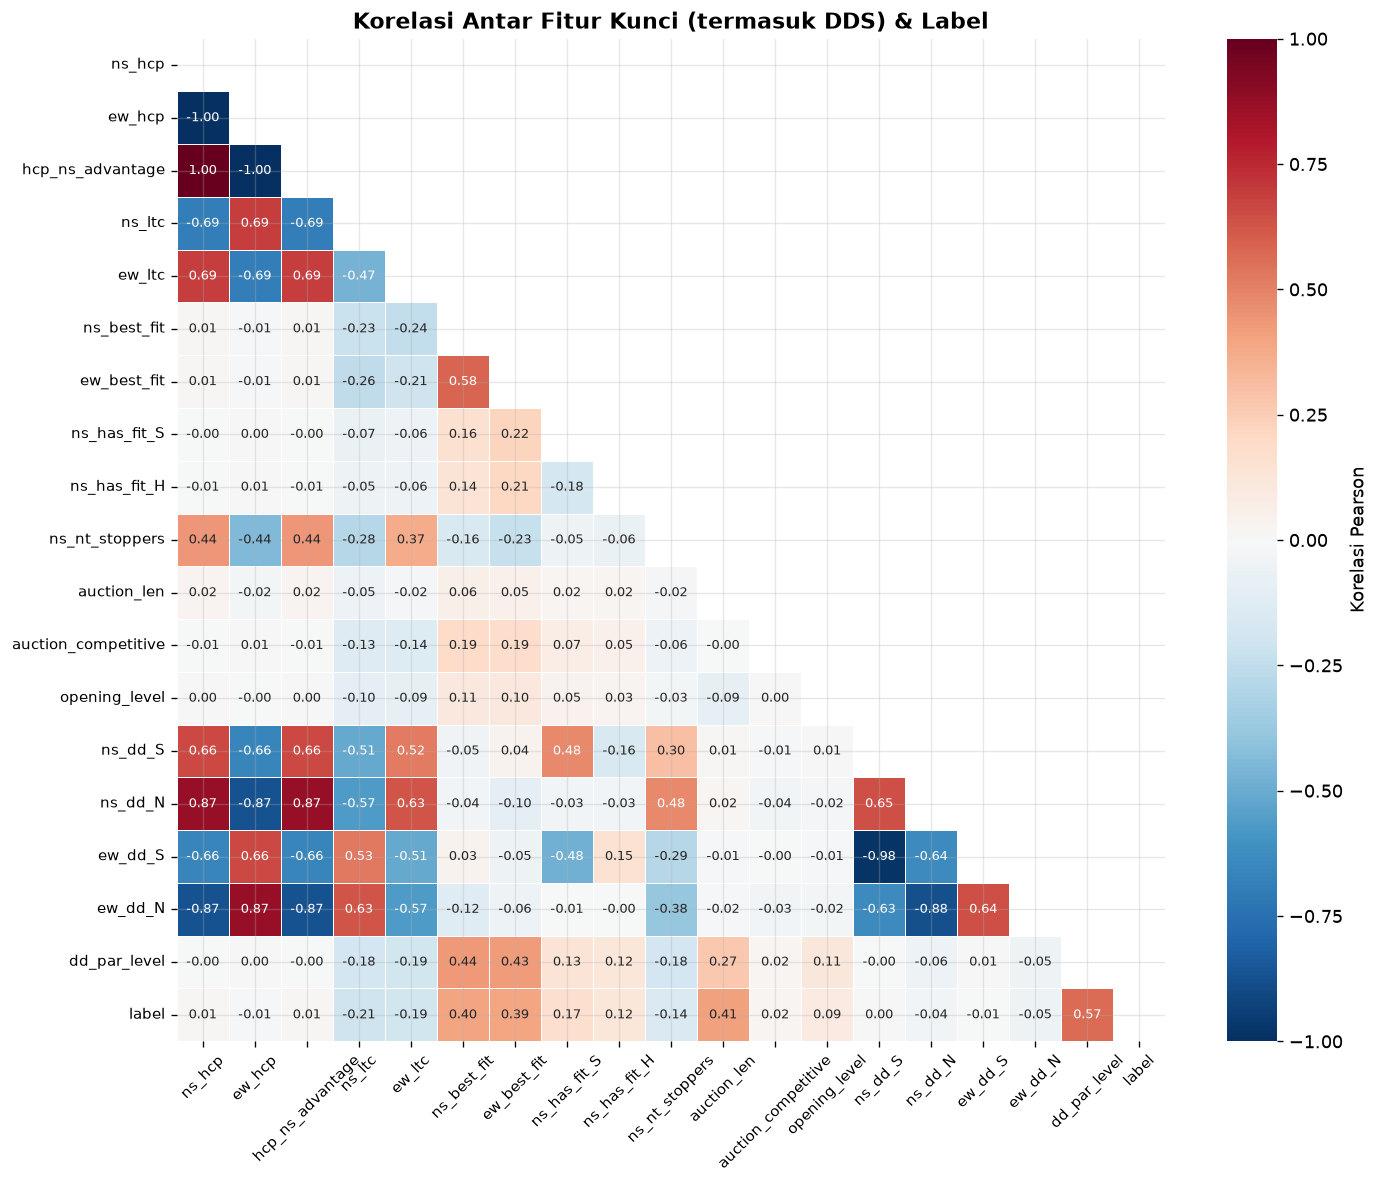

Korelasi fitur DDS dengan label:
  ns_dd_S        : +0.002
  ns_dd_N        : -0.037
  ew_dd_S        : -0.006
  ew_dd_N        : -0.050
  dd_par_level   : +0.569


In [14]:
# Korelasi fitur-fitur kunci (termasuk DDS) dengan label numerik
key_features = [
    'ns_hcp', 'ew_hcp', 'hcp_ns_advantage',
    'ns_ltc', 'ew_ltc',
    'ns_best_fit', 'ew_best_fit',
    'ns_has_fit_S', 'ns_has_fit_H',
    'ns_nt_stoppers',
    'auction_len', 'auction_competitive',
    'opening_level',
    'ns_dd_S', 'ns_dd_N', 'ew_dd_S', 'ew_dd_N',
    'dd_par_level',
]

corr_df = df[key_features + ['label']].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.zeros_like(corr_df, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_df, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Korelasi Pearson'},
    ax=ax, annot_kws={'size': 8},
)
ax.set_title('Korelasi Antar Fitur Kunci (termasuk DDS) & Label', fontweight='bold', fontsize=13)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig(OUT / 'nb02_correlation.png', bbox_inches='tight')
plt.show()

print('Korelasi fitur DDS dengan label:')
for f in ['ns_dd_S', 'ns_dd_N', 'ew_dd_S', 'ew_dd_N', 'dd_par_level']:
    print(f'  {f:<15}: {corr_df.loc[f, "label"]:+.3f}')


---
## 8. Provenance Data — Sumber & Event Turnamen

Breakdown sumber data mentah (LIN vs PBN) dan daftar event/turnamen asal
data PBN — untuk transparansi provenance. Lihat `CLAUDE.md` "Status
Proyek" untuk narasi akuisisi data lengkap dan proses verifikasi tiap
sumber (liveness situs, cek kontaminasi bot GIB/WBridge5, validasi
integritas kartu).


In [15]:
import re
from collections import defaultdict

raw_dir     = ROOT / 'data' / 'raw'
raw_pbn_dir = ROOT / 'data' / 'raw_pbn'

lin_files = sorted(raw_dir.glob('*.lin'))
pbn_files_all = sorted(set(raw_pbn_dir.glob('*.pbn')) | set(raw_pbn_dir.glob('*.PBN')))

def pbn_source(fname: str) -> str:
    if fname.startswith('angelfire_'):
        return 'angelfire.com (Wayback Machine)'
    if fname.startswith(('etc', 'eyc')) or 'tistis' in fname.lower():
        return 'tistis.nl'
    return 'computerbridge.se'

pbn_source_counts = Counter(pbn_source(f.name) for f in pbn_files_all)

print('=== Sumber File Mentah ===')
print(f'  LIN (BBO vugraph)         : {len(lin_files):>5,} file')
for src, n in pbn_source_counts.most_common():
    print(f'  PBN ({src:<28}) : {n:>5,} file')
print(f'  {"Total PBN":<32}: {len(pbn_files_all):>5,} file')
print(f'  {"Total keseluruhan":<32}: {len(lin_files) + len(pbn_files_all):>5,} file')


=== Sumber File Mentah ===
  LIN (BBO vugraph)         :   606 file
  PBN (angelfire.com (Wayback Machine)) : 1,178 file
  PBN (tistis.nl                   ) :   169 file
  PBN (computerbridge.se           ) :    43 file
  Total PBN                       : 1,390 file
  Total keseluruhan               : 1,996 file


In [16]:
event_re = re.compile(r'\[Event\s+"([^"]*)"\]')

event_files = defaultdict(set)
event_by_source = defaultdict(lambda: defaultdict(set))

for f in pbn_files_all:
    try:
        text = f.read_text(encoding='utf-8', errors='ignore')
    except Exception:
        continue
    # PBN "#" shorthand = "sama seperti board sebelumnya" -- resolve lewat
    # nilai pertama yang bukan "#" (sama seperti carry-forward di PBNParser),
    # bukan dihitung sebagai event literal "#".
    raw_events = event_re.findall(text)
    resolved = next((e for e in raw_events if e != '#' and e.strip()), '(tidak diketahui)')
    src = pbn_source(f.name)
    event_files[resolved].add(f.name)
    event_by_source[resolved][src].add(f.name)

print(f'Total event turnamen unik (file PBN): {len(event_files)}')
print(f'Total file PBN dengan event teridentifikasi: {sum(len(v) for v in event_files.values())}')


Total event turnamen unik (file PBN): 89
Total file PBN dengan event teridentifikasi: 1390


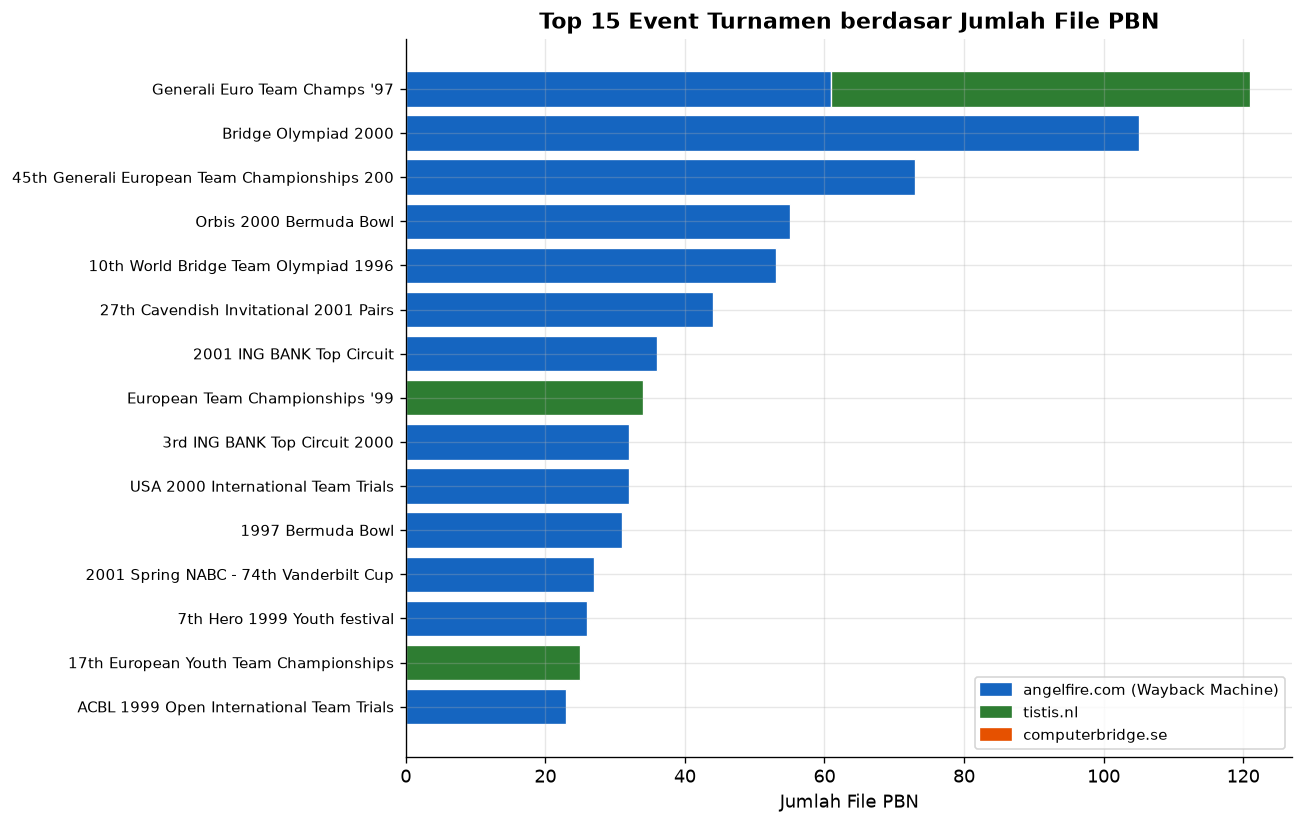


=== Top 15 Event (jumlah file PBN) ===
  [121] Generali Euro Team Champs '97  (angelfire.com (Wayback Machine)=61, tistis.nl=60)
  [105] Bridge Olympiad 2000  (angelfire.com (Wayback Machine)=105)
  [ 73] 45th Generali European Team Championships 2001  (angelfire.com (Wayback Machine)=73)
  [ 55] Orbis 2000 Bermuda Bowl  (angelfire.com (Wayback Machine)=55)
  [ 53] 10th World Bridge Team Olympiad 1996  (angelfire.com (Wayback Machine)=53)
  [ 44] 27th Cavendish Invitational 2001 Pairs  (angelfire.com (Wayback Machine)=44)
  [ 36] 2001 ING BANK Top Circuit  (angelfire.com (Wayback Machine)=36)
  [ 34] European Team Championships '99  (tistis.nl=34)
  [ 32] 3rd ING BANK Top Circuit 2000  (angelfire.com (Wayback Machine)=32)
  [ 32] USA 2000 International Team Trials  (angelfire.com (Wayback Machine)=32)
  [ 31] 1997 Bermuda Bowl  (angelfire.com (Wayback Machine)=31)
  [ 27] 2001 Spring NABC - 74th Vanderbilt Cup  (angelfire.com (Wayback Machine)=27)
  [ 26] 7th Hero 1999 Youth festival 

In [17]:
N_TOP = 15
top_events = sorted(event_files.items(), key=lambda kv: -len(kv[1]))[:N_TOP]

source_colors = {
    'angelfire.com (Wayback Machine)': '#1565C0',
    'tistis.nl': '#2E7D32',
    'computerbridge.se': '#E65100',
}

fig, ax = plt.subplots(figsize=(11, 7))
y_pos = np.arange(len(top_events))

for i, (event, files) in enumerate(top_events):
    # satu event bisa datang dari >1 sumber (mis. mirror angelfire+tistis) --
    # gambar sebagai stacked bar per sumber
    left = 0
    for src, color in source_colors.items():
        n = len(event_by_source[event].get(src, set()))
        if n:
            ax.barh(i, n, left=left, color=color, edgecolor='white', linewidth=0.8)
            left += n

ax.set_yticks(y_pos)
ax.set_yticklabels([ev[:45] for ev, _ in top_events], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Jumlah File PBN')
ax.set_title(f'Top {N_TOP} Event Turnamen berdasar Jumlah File PBN', fontweight='bold', fontsize=13)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=s) for s, c in source_colors.items()], fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(OUT / 'nb02_data_provenance.png', bbox_inches='tight')
plt.show()

print(f'\n=== Top {N_TOP} Event (jumlah file PBN) ===')
for event, files in top_events:
    src_summary = ', '.join(f'{s}={len(fs)}' for s, fs in event_by_source[event].items())
    print(f'  [{len(files):>3}] {event}  ({src_summary})')


---
## Ringkasan Notebook 2

**Temuan EDA:**
- **HCP** tetap prediktor utama — makin tinggi HCP NS, makin besar kemungkinan kontrak tinggi
- **Suit Fit (>=8 kartu)** sangat berkorelasi dengan kontrak major suit (4S, 4H)
- **NT Stopper** — mayoritas kontrak NT dimainkan oleh NS yang punya stopper di semua 4 suit
- **LTC** berbanding terbalik dengan level kontrak
- **DDS**: trik double-dummy TIDAK identik dengan HCP (korelasi < 1.0) — membawa
  informasi tambahan; level kontrak par vs level aktual dibid manusia
  tidak selalu sama persis (lihat notebook 01, bagian 6) — mengonfirmasi
  ambiguitas bidding manusia yang jadi alasan DDS ditambahkan
- **Class imbalance** cukup ekstrem: 3N ~20%, Grand Slam <1%

**Dataset:**
- **182 fitur** numerik/biner (164 kanonik + 18 DDS), tidak perlu encoding tambahan
- Train 70% / Val 15% / Test 15% — split **group-aware** (StratifiedGroupKFold
  per papan fisik, supaya pasangan open/closed-room BBO tidak bocor lintas split)

**Lanjut ke:** `03_modeling.ipynb` (folder ini) -> Training RF, XGBoost, LightGBM
